In [38]:
"""
Heart Disease Prediction Using Machine Learning Classification Models
Complete ML Pipeline
"""

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.get_logger().setLevel('ERROR')

MODEL_NAMES = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Neural Network']

In [39]:
print("  HEART DISEASE PREDICTION — ML PIPELINE")

df = pd.read_csv(r'C:\Users\soham parab\Downloads\heart.csv')
df.columns = df.columns.str.strip()

print(f"\n📊 Dataset shape : {df.shape}")
print(f"   Missing values : {df.isnull().sum().sum()}")
print(f"   Duplicates     : {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f"   Shape after cleaning: {df.shape}")

print("\n   Target distribution:")
print(df['target'].value_counts().rename({0: 'No Disease (0)', 1: 'Disease (1)'}))

  HEART DISEASE PREDICTION — ML PIPELINE

📊 Dataset shape : (303, 14)
   Missing values : 0
   Duplicates     : 1
   Shape after cleaning: (302, 14)

   Target distribution:
target
Disease (1)       164
No Disease (0)    138
Name: count, dtype: int64



────────────────────────────────────────────────────────────
  EDA
────────────────────────────────────────────────────────────


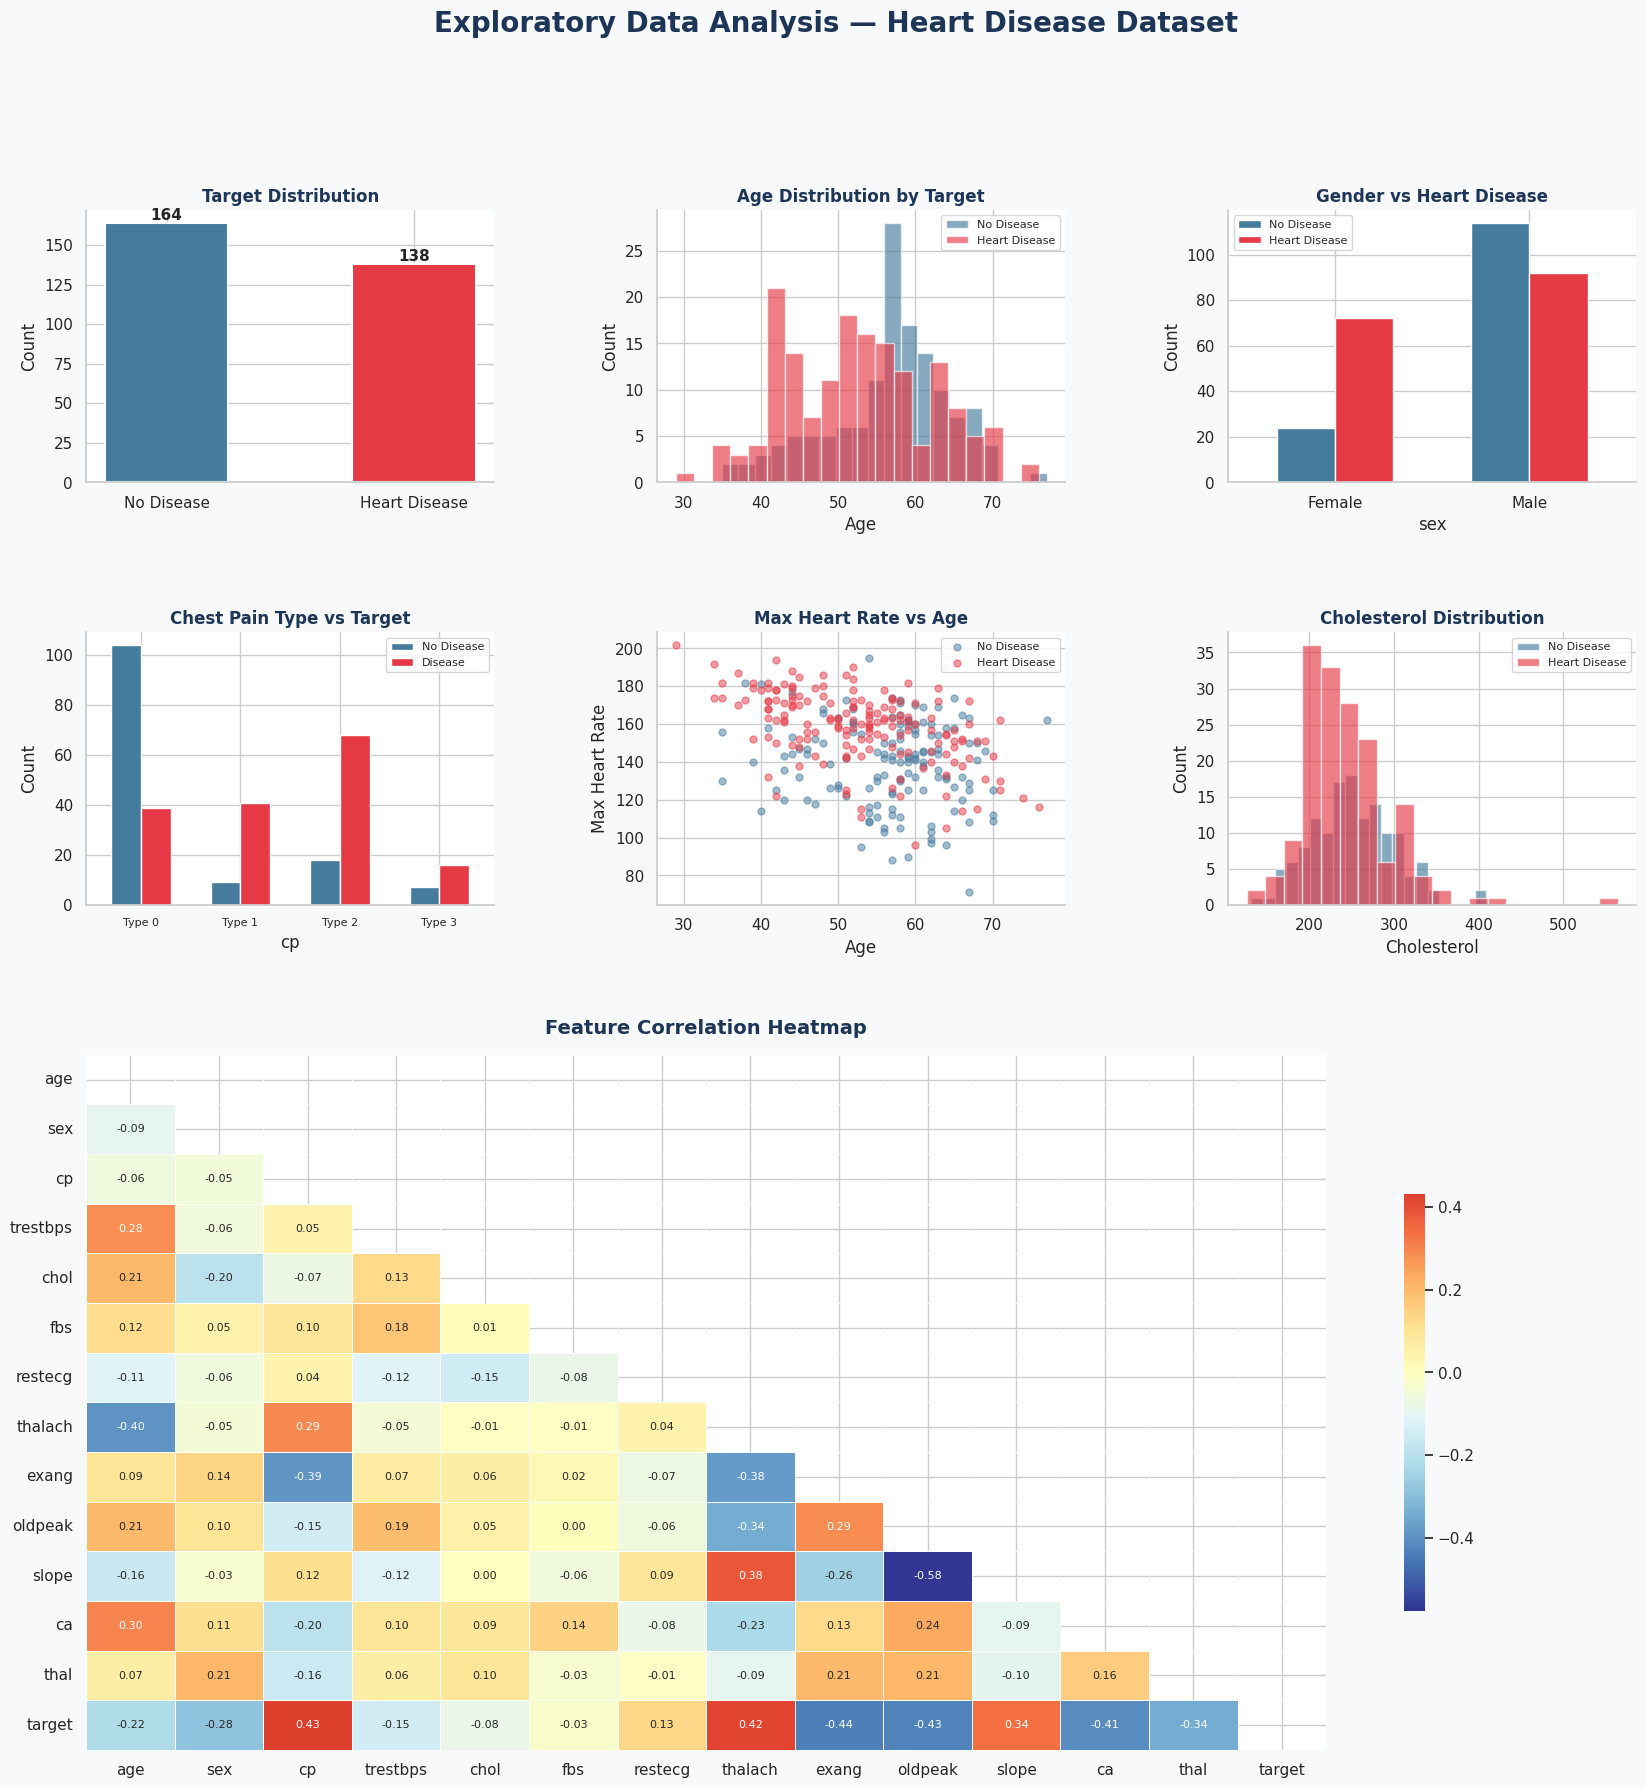

In [40]:
print("\n" + "─" * 60)
print("  EDA")
print("─" * 60)

# ── Figure 1: EDA Overview ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor(COLORS['bg'])
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.4)
fig.suptitle('Exploratory Data Analysis — Heart Disease Dataset',
             fontsize=20, fontweight='bold', color=COLORS['accent'], y=0.98)

# (a) Target distribution
ax0 = fig.add_subplot(gs[0, 0])
counts = df['target'].value_counts()
bars = ax0.bar(['No Disease', 'Heart Disease'], counts.values,
               color=[COLORS['secondary'], COLORS['primary']], width=0.5,
               edgecolor='white', linewidth=1.5)
for b in bars:
    ax0.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
             f'{int(b.get_height())}', ha='center', fontweight='bold', fontsize=11)
ax0.set_title('Target Distribution', fontweight='bold', color=COLORS['accent'])
ax0.set_ylabel('Count')

# (b) Age distribution by target
ax1 = fig.add_subplot(gs[0, 1])
for t, c, lbl in zip([0,1], [COLORS['secondary'], COLORS['primary']],
                     ['No Disease', 'Heart Disease']):
    ax1.hist(df[df['target']==t]['age'], bins=20, alpha=0.65, color=c, label=lbl, edgecolor='white')
ax1.set_title('Age Distribution by Target', fontweight='bold', color=COLORS['accent'])
ax1.set_xlabel('Age'); ax1.set_ylabel('Count'); ax1.legend(fontsize=8)

# (c) Gender vs Target
ax2 = fig.add_subplot(gs[0, 2])
gender_target = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
gender_target.plot(kind='bar', ax=ax2, color=[COLORS['secondary'], COLORS['primary']],
                   edgecolor='white', width=0.6, legend=True)
ax2.set_xticklabels(['Female', 'Male'], rotation=0)
ax2.set_title('Gender vs Heart Disease', fontweight='bold', color=COLORS['accent'])
ax2.set_ylabel('Count'); ax2.legend(['No Disease', 'Heart Disease'], fontsize=8)

# (d) Chest Pain vs Target
ax3 = fig.add_subplot(gs[1, 0])
cp_target = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_target.plot(kind='bar', ax=ax3, color=[COLORS['secondary'], COLORS['primary']],
               edgecolor='white', width=0.6)
ax3.set_xticklabels(['Type 0','Type 1','Type 2','Type 3'], rotation=0, fontsize=8)
ax3.set_title('Chest Pain Type vs Target', fontweight='bold', color=COLORS['accent'])
ax3.set_ylabel('Count'); ax3.legend(['No Disease', 'Disease'], fontsize=8)

# (e) Max Heart Rate vs Age
ax4 = fig.add_subplot(gs[1, 1])
for t, c, lbl in zip([0,1], [COLORS['secondary'], COLORS['primary']],
                     ['No Disease', 'Heart Disease']):
    sub = df[df['target']==t]
    ax4.scatter(sub['age'], sub['thalach'], alpha=0.5, color=c, s=25, label=lbl)
ax4.set_title('Max Heart Rate vs Age', fontweight='bold', color=COLORS['accent'])
ax4.set_xlabel('Age'); ax4.set_ylabel('Max Heart Rate'); ax4.legend(fontsize=8)

# (f) Cholesterol distribution
ax5 = fig.add_subplot(gs[1, 2])
for t, c, lbl in zip([0,1], [COLORS['secondary'], COLORS['primary']],
                     ['No Disease', 'Heart Disease']):
    ax5.hist(df[df['target']==t]['chol'], bins=20, alpha=0.65, color=c, label=lbl, edgecolor='white')
ax5.set_title('Cholesterol Distribution', fontweight='bold', color=COLORS['accent'])
ax5.set_xlabel('Cholesterol'); ax5.set_ylabel('Count'); ax5.legend(fontsize=8)

# (g) Correlation heatmap
ax6 = fig.add_subplot(gs[2:, :])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax6, annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.6})
ax6.set_title('Feature Correlation Heatmap', fontweight='bold',
              color=COLORS['accent'], fontsize=14, pad=15)

plt.show()

In [41]:
print("\n" + "─" * 60)
print("  PREPROCESSING")
print("─" * 60)

X = df.drop('target', axis=1)
y = df['target']

# One-hot encode categoricals
cat_cols = ['cp', 'thal', 'restecg', 'slope']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"   Features after encoding: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"   Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


────────────────────────────────────────────────────────────
  PREPROCESSING
────────────────────────────────────────────────────────────
   Features after encoding: 19
   Train size: 241 | Test size: 61


In [42]:
print("\n" + "─" * 60)
print("  MODEL TRAINING")
print("─" * 60)

results = {}

# ── Logistic Regression ───────────────────────────────────────────────────────
print("\n   [1/4] Logistic Regression ...")
lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
lr_gs = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                     lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_gs.fit(X_train_sc, y_train)
lr_model = lr_gs.best_estimator_
lr_pred  = lr_model.predict(X_test_sc)
lr_prob  = lr_model.predict_proba(X_test_sc)[:, 1]
print(f"      Best params: {lr_gs.best_params_}")
print(f"      Test Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
results['Logistic Regression'] = {
    'model': lr_model, 'pred': lr_pred, 'prob': lr_prob,
    'acc': accuracy_score(y_test, lr_pred),
    'prec': precision_score(y_test, lr_pred),
    'rec': recall_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred),
    'auc': roc_auc_score(y_test, lr_prob),
    'cm': confusion_matrix(y_test, lr_pred)
}

# ── Decision Tree ─────────────────────────────────────────────────────────────
print("\n   [2/4] Decision Tree ...")
dt_params = {'max_depth': [3, 5, 7, 10, None],
             'min_samples_split': [2, 5, 10],
             'criterion': ['gini', 'entropy']}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_gs.fit(X_train_sc, y_train)
dt_model = dt_gs.best_estimator_
dt_pred  = dt_model.predict(X_test_sc)
dt_prob  = dt_model.predict_proba(X_test_sc)[:, 1]
print(f"      Best params: {dt_gs.best_params_}")
print(f"      Test Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
results['Decision Tree'] = {
    'model': dt_model, 'pred': dt_pred, 'prob': dt_prob,
    'acc': accuracy_score(y_test, dt_pred),
    'prec': precision_score(y_test, dt_pred),
    'rec': recall_score(y_test, dt_pred),
    'f1': f1_score(y_test, dt_pred),
    'auc': roc_auc_score(y_test, dt_prob),
    'cm': confusion_matrix(y_test, dt_pred)
}

# ── Random Forest ─────────────────────────────────────────────────────────────
print("\n   [3/4] Random Forest ...")
rf_params = {'n_estimators': [100, 200],
             'max_depth': [5, 10, None],
             'min_samples_split': [2, 5]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_train_sc, y_train)
rf_model = rf_gs.best_estimator_
rf_pred  = rf_model.predict(X_test_sc)
rf_prob  = rf_model.predict_proba(X_test_sc)[:, 1]
print(f"      Best params: {rf_gs.best_params_}")
print(f"      Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
results['Random Forest'] = {
    'model': rf_model, 'pred': rf_pred, 'prob': rf_prob,
    'acc': accuracy_score(y_test, rf_pred),
    'prec': precision_score(y_test, rf_pred),
    'rec': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred),
    'auc': roc_auc_score(y_test, rf_prob),
    'cm': confusion_matrix(y_test, rf_pred)
}

# ── Neural Network ────────────────────────────────────────────────────────────
print("\n   [4/4] Neural Network ...")
tf.random.set_seed(42)
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss')
history = nn_model.fit(
    X_train_sc, y_train,
    epochs=150, batch_size=32,
    validation_split=0.15,
    callbacks=[es], verbose=0
)
nn_prob = nn_model.predict(X_test_sc, verbose=0).flatten()
nn_pred = (nn_prob >= 0.5).astype(int)
print(f"      Stopped at epoch: {len(history.history['loss'])}")
print(f"      Test Accuracy: {accuracy_score(y_test, nn_pred):.4f}")
results['Neural Network'] = {
    'model': nn_model, 'pred': nn_pred, 'prob': nn_prob,
    'acc': accuracy_score(y_test, nn_pred),
    'prec': precision_score(y_test, nn_pred),
    'rec': recall_score(y_test, nn_pred),
    'f1': f1_score(y_test, nn_pred),
    'auc': roc_auc_score(y_test, nn_prob),
    'cm': confusion_matrix(y_test, nn_pred),
    'history': history
}


────────────────────────────────────────────────────────────
  MODEL TRAINING
────────────────────────────────────────────────────────────

   [1/4] Logistic Regression ...
      Best params: {'C': 0.1, 'solver': 'liblinear'}
      Test Accuracy: 0.8033

   [2/4] Decision Tree ...
      Best params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
      Test Accuracy: 0.6885

   [3/4] Random Forest ...
      Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
      Test Accuracy: 0.7705

   [4/4] Neural Network ...
      Stopped at epoch: 53
      Test Accuracy: 0.8033



────────────────────────────────────────────────────────────
  MODEL EVALUATION
────────────────────────────────────────────────────────────


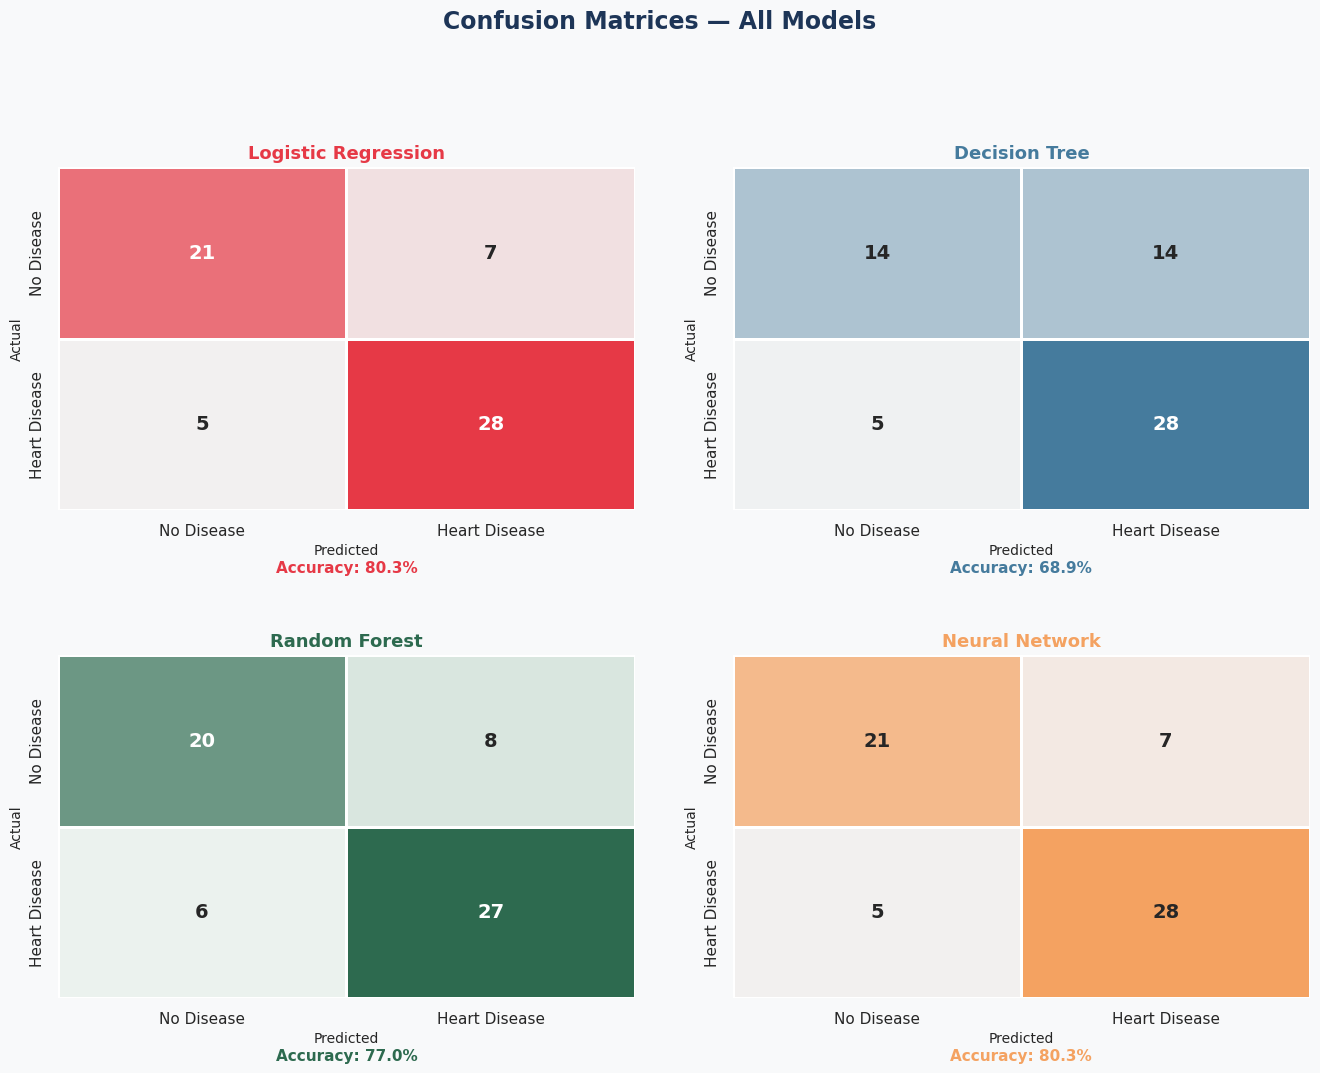

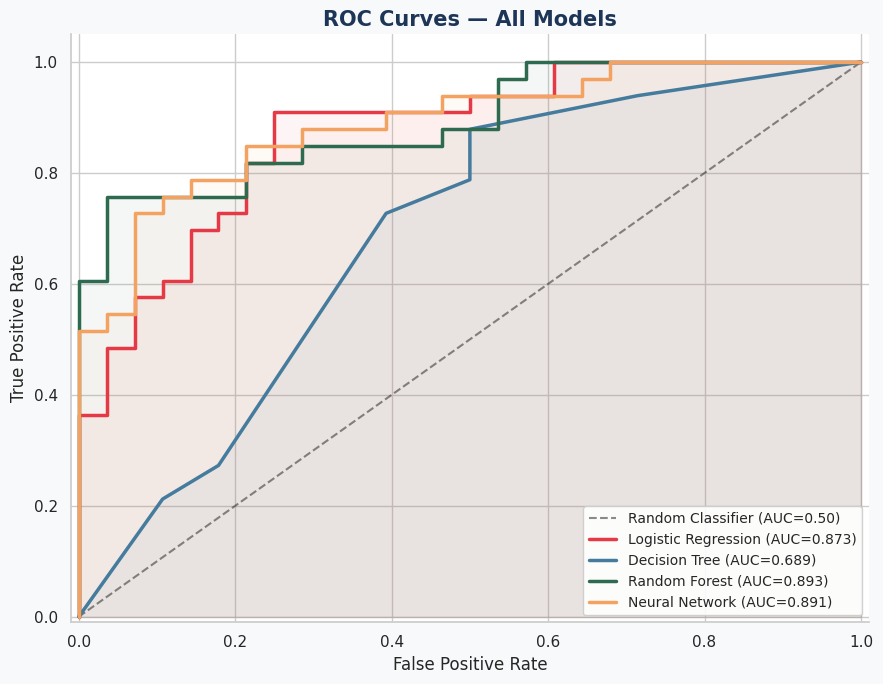

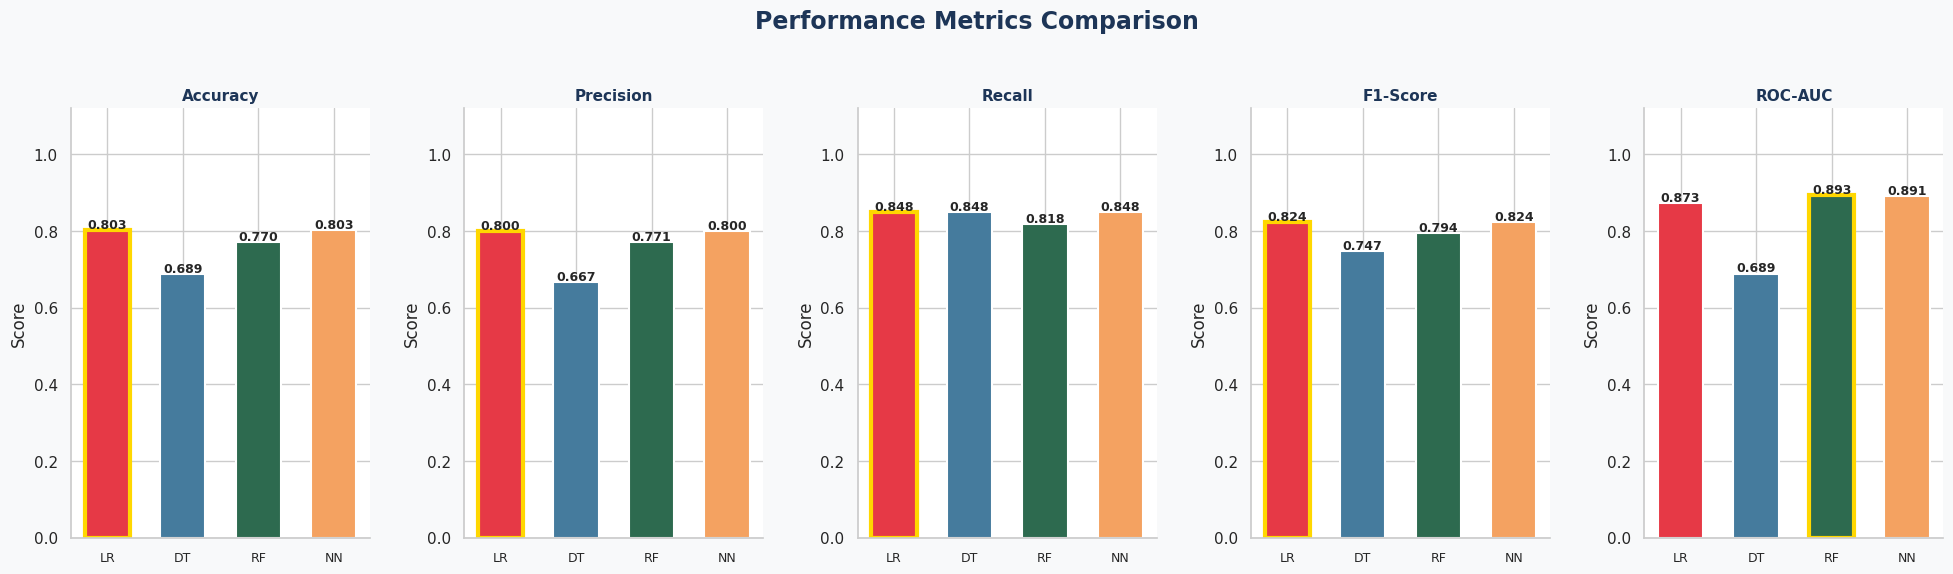

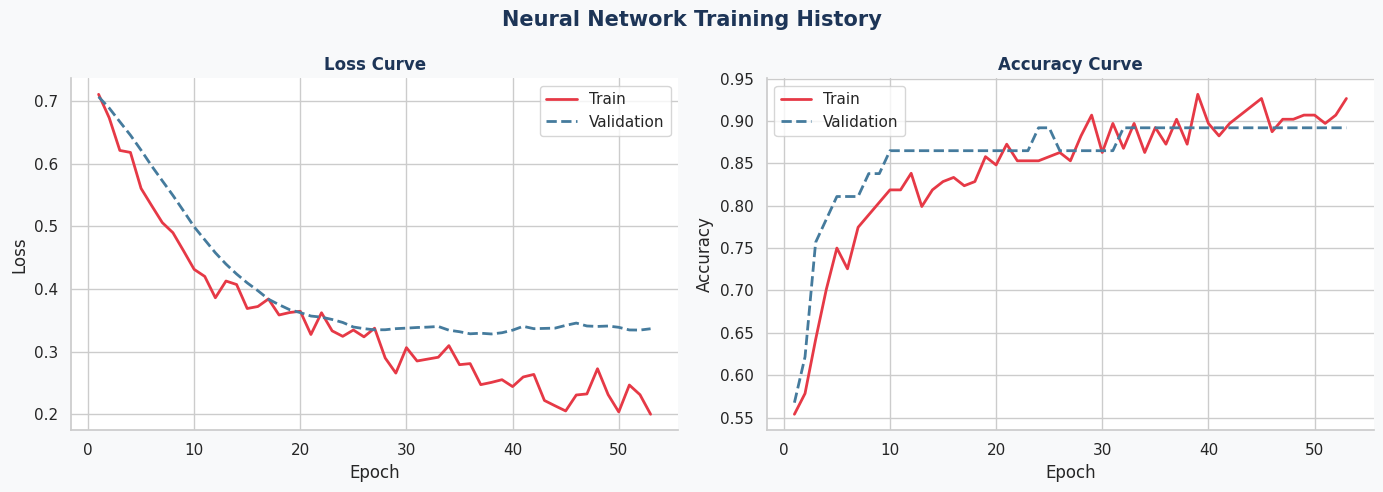

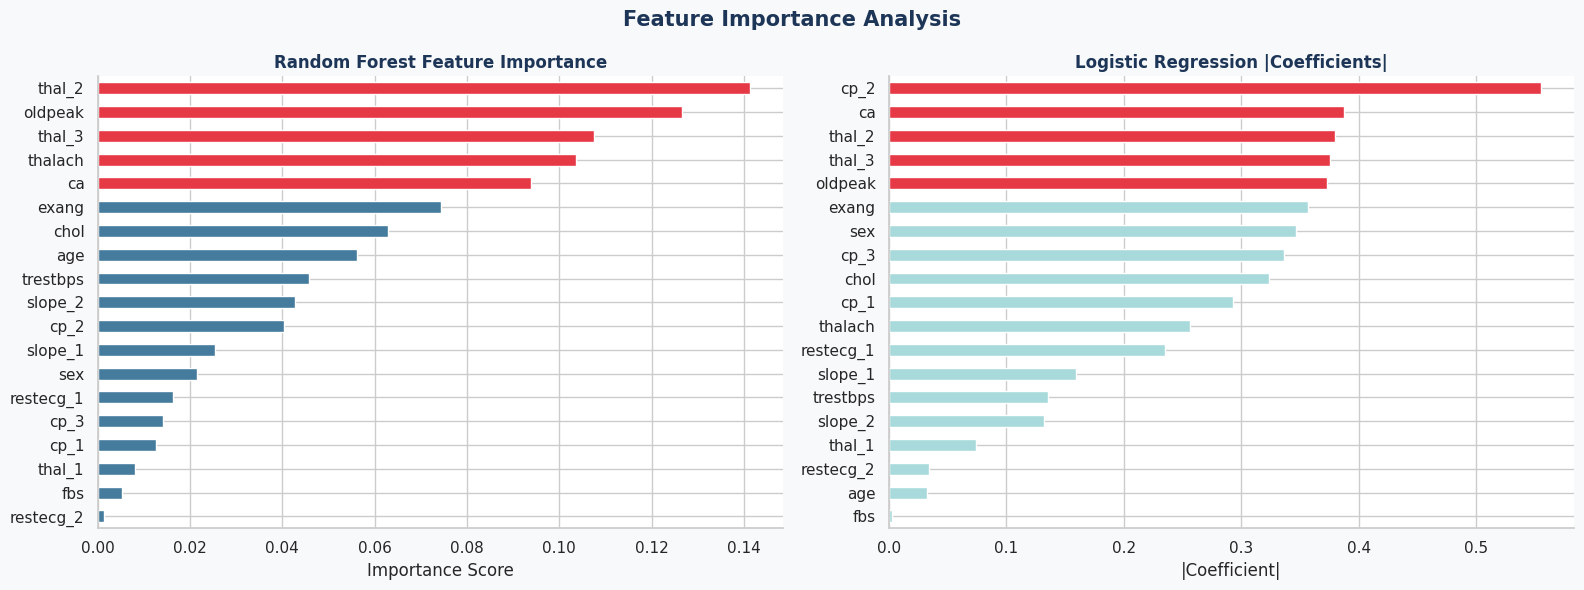

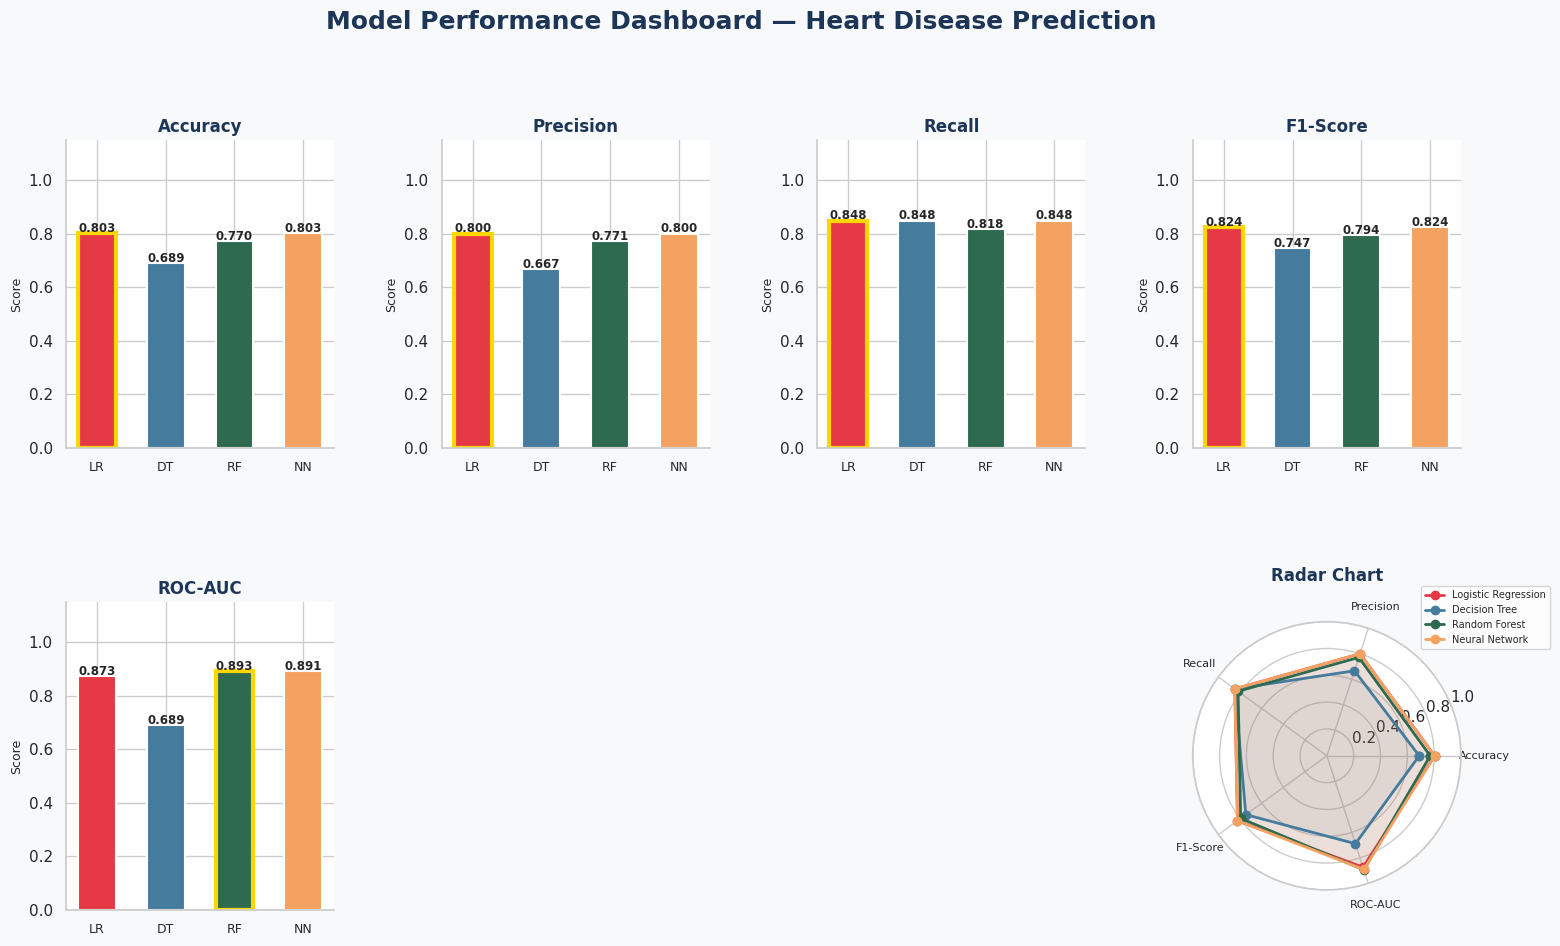

   All evaluation charts displayed


In [43]:
print("\n" + "─" * 60)
print("  MODEL EVALUATION")
print("─" * 60)

metrics = ['acc', 'prec', 'rec', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# ── Figure 2: Confusion Matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Confusion Matrices — All Models', fontsize=17,
             fontweight='bold', color=COLORS['accent'], y=1.01)
for ax, (name, res), col in zip(axes.flatten(), results.items(), COLORS['models']):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(col, as_cmap=True),
                cbar=False, linewidths=2, linecolor='white',
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontweight='bold', color=col, fontsize=13)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('Actual', fontsize=10)
    acc = res['acc']
    ax.text(0.5, -0.18, f"Accuracy: {acc:.1%}", transform=ax.transAxes,
            ha='center', fontsize=11, color=col, fontweight='bold')
plt.tight_layout(pad=3)
plt.show()

# ── Figure 3: ROC Curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor('#FFFFFF')
ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC=0.50)')
for (name, res), col in zip(results.items(), COLORS['models']):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax.plot(fpr, tpr, color=col, lw=2.5,
            label=f"{name} (AUC={res['auc']:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.05, color=col)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold', color=COLORS['accent'])
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.05)
plt.tight_layout()
plt.show()

# ── Figure 4: Metrics Comparison Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Performance Metrics Comparison', fontsize=17,
             fontweight='bold', color=COLORS['accent'])
for ax, metric, label in zip(axes, metrics, metric_labels):
    vals = [results[n][metric] for n in MODEL_NAMES]
    bars = ax.bar(range(4), vals, color=COLORS['models'], edgecolor='white',
                  linewidth=1.5, width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['LR', 'DT', 'RF', 'NN'], fontsize=9)
    ax.set_title(label, fontweight='bold', color=COLORS['accent'], fontsize=11)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
    best_idx = np.argmax(vals)
    axes_list = list(bars)
    axes_list[best_idx].set_edgecolor('gold')
    axes_list[best_idx].set_linewidth(3)
plt.tight_layout(pad=2)
plt.show()

# ── Figure 5: Neural Network Training History ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Neural Network Training History', fontsize=15,
             fontweight='bold', color=COLORS['accent'])
h = results['Neural Network']['history'].history
epochs = range(1, len(h['loss'])+1)
for ax, train_key, val_key, ylabel, title in zip(
        axes,
        ['loss', 'accuracy'], ['val_loss', 'val_accuracy'],
        ['Loss', 'Accuracy'], ['Loss Curve', 'Accuracy Curve']):
    ax.plot(epochs, h[train_key], color=COLORS['primary'], lw=2, label='Train')
    ax.plot(epochs, h[val_key], color=COLORS['secondary'], lw=2,
            linestyle='--', label='Validation')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', color=COLORS['accent'])
    ax.legend()
plt.tight_layout()
plt.show()

# ── Figure 6: Feature Importance (Random Forest) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Feature Importance Analysis', fontsize=15,
             fontweight='bold', color=COLORS['accent'])

# RF importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_bar = [COLORS['primary'] if v >= feat_imp.quantile(0.75) else COLORS['secondary']
              for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=axes[0], color=colors_bar, edgecolor='white')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold', color=COLORS['accent'])
axes[0].set_xlabel('Importance Score')

# LR coefficients
lr_coef = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns).sort_values(ascending=True)
colors_bar2 = [COLORS['primary'] if v >= lr_coef.quantile(0.75) else COLORS['light']
               for v in lr_coef.values]
lr_coef.plot(kind='barh', ax=axes[1], color=colors_bar2, edgecolor='white')
axes[1].set_title('Logistic Regression |Coefficients|', fontweight='bold', color=COLORS['accent'])
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

# ── Figure 7: Comprehensive Model Summary Dashboard ───────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(COLORS['bg'])
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle('Model Performance Dashboard — Heart Disease Prediction',
             fontsize=18, fontweight='bold', color=COLORS['accent'], y=1.01)

metric_list = [('acc','Accuracy'), ('prec','Precision'), ('rec','Recall'),
               ('f1','F1-Score'), ('auc','ROC-AUC')]

for i, (metric, label) in enumerate(metric_list):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    vals = [results[n][metric] for n in MODEL_NAMES]
    bars = ax.bar(MODEL_NAMES, vals, color=COLORS['models'], edgecolor='white',
                  linewidth=1.5, width=0.55)
    best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', fontsize=8.5, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['LR','DT','RF','NN'], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontweight='bold', color=COLORS['accent'])
    ax.set_ylabel('Score', fontsize=9)

# Radar chart (spider plot)
ax_radar = fig.add_subplot(gs[1, 3], polar=True)
N = 5
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_labels, fontsize=8)
ax_radar.set_ylim(0, 1)
for (name, res), col in zip(results.items(), COLORS['models']):
    vals_r = [res[m] for m in metrics] + [res[metrics[0]]]
    ax_radar.plot(angles, vals_r, 'o-', color=col, lw=2, label=name)
    ax_radar.fill(angles, vals_r, alpha=0.08, color=col)
ax_radar.set_title('Radar Chart', fontweight='bold', color=COLORS['accent'], pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=7)

plt.show()

print("   All evaluation charts displayed")

  FINAL RESULTS SUMMARY
              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.8033    0.8000 0.8485   0.8235  0.8734
      Decision Tree   0.6885    0.6667 0.8485   0.7467  0.6889
      Random Forest   0.7705    0.7714 0.8182   0.7941  0.8929
     Neural Network   0.8033    0.8000 0.8485   0.8235  0.8907

🏆 Best Model (by ROC-AUC): Random Forest — AUC = 0.8929


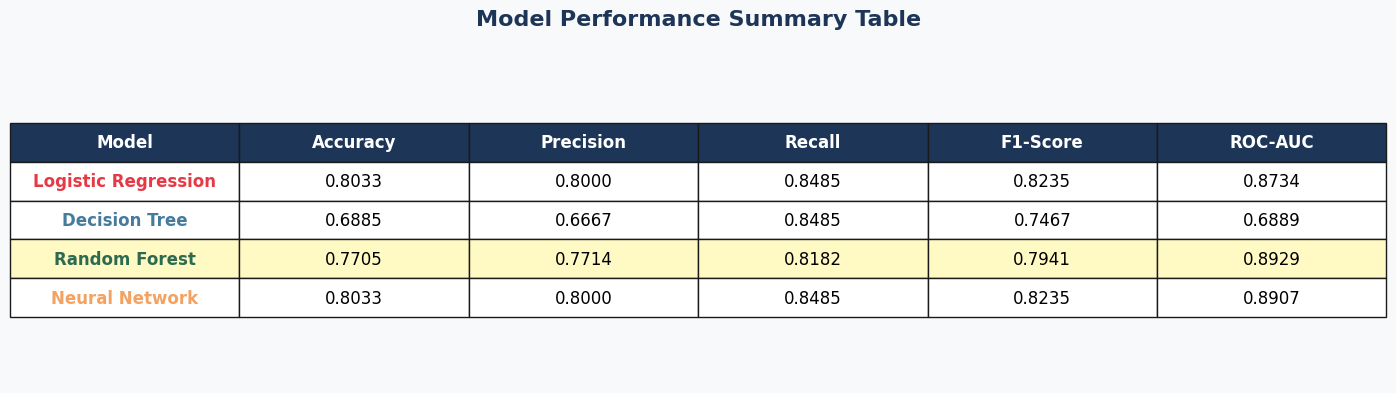

In [48]:
print("  FINAL RESULTS SUMMARY")
summary_df = pd.DataFrame({
    'Model': MODEL_NAMES,
    'Accuracy':  [f"{results[n]['acc']:.4f}"  for n in MODEL_NAMES],
    'Precision': [f"{results[n]['prec']:.4f}" for n in MODEL_NAMES],
    'Recall':    [f"{results[n]['rec']:.4f}"  for n in MODEL_NAMES],
    'F1-Score':  [f"{results[n]['f1']:.4f}"   for n in MODEL_NAMES],
    'ROC-AUC':   [f"{results[n]['auc']:.4f}"  for n in MODEL_NAMES],
})
print(summary_df.to_string(index=False))

best_name = max(results, key=lambda n: results[n]['auc'])
print(f"\n🏆 Best Model (by ROC-AUC): {best_name} — AUC = {results[best_name]['auc']:.4f}")

# ── Figure 8: Summary Table as Image ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(COLORS['bg'])
ax.axis('off')
ax.set_facecolor(COLORS['bg'])
fig.suptitle('Model Performance Summary Table', fontsize=16,
             fontweight='bold', color=COLORS['accent'])

col_labels = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
table_data = [[n,
               f"{results[n]['acc']:.4f}",
               f"{results[n]['prec']:.4f}",
               f"{results[n]['rec']:.4f}",
               f"{results[n]['f1']:.4f}",
               f"{results[n]['auc']:.4f}"]
              for n in MODEL_NAMES]

table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(12)
table.scale(1.2, 2.2)

# Style header
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(COLORS['accent'])
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Style rows
for i, (name, row) in enumerate(zip(MODEL_NAMES, table_data), 1):
    best_auc = max(float(results[n]['auc']) for n in MODEL_NAMES)
    row_color = '#FFF9C4' if float(results[name]['auc']) == best_auc else 'white'
    for j in range(len(col_labels)):
        table[(i, j)].set_facecolor(row_color)
        table[(i, j)].set_text_props(
            color=COLORS['models'][i-1] if j == 0 else 'black',
            fontweight='bold' if j == 0 else 'normal')

plt.tight_layout()
plt.show()

In [47]:
input_dict = {
    'age':      [52],
    'sex':      [1],
    'trestbps': [250],
    'chol':     [212],
    'fbs':      [0],
    'thalach':  [268],
    'exang':    [0],
    'oldpeak':  [1.0],
    'ca':       [2],
    'cp':       [0],       # categorical
    'thal':     [3],       # categorical
    'restecg':  [1],       # categorical
    'slope':    [2],       # categorical
}

input_df = pd.DataFrame(input_dict)

# ── Step 2: One-hot encode (same as training) ──
cat_cols = ['cp', 'thal', 'restecg', 'slope']
input_encoded = pd.get_dummies(input_df, columns=cat_cols, drop_first=True)

# ── Step 3: Align columns with training data ──
# Adds any missing columns as 0, removes extra columns
input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)

# ── Step 4: Scale the input ──
input_scaled = scaler.transform(input_encoded)

# ── Step 5: Choose your model and predict ──
# Change this to: lr_model / dt_model / rf_model / nn_model
chosen_model = nn_model        # 🏆 Best model (highest ROC-AUC)

# ── Step 6: Make prediction ──
if chosen_model == nn_model:
    # Neural Network returns probability directly
    probability = chosen_model.predict(input_scaled, verbose=0)[0][0]
    prediction = 1 if probability >= 0.5 else 0
    print(f"Prediction Probability: No Disease = {1-probability:.2%} | Heart Disease = {probability:.2%}")
else:
    prediction = chosen_model.predict(input_scaled)[0]
    probability = chosen_model.predict_proba(input_scaled)[0]
    print(f"Prediction Probability: No Disease = {probability[0]:.2%} | Heart Disease = {probability[1]:.2%}")

# ── Step 7: Output result ──
print()
if prediction == 1:
    print("⚠️ The model predicts: Patient HAS Heart Disease")
else:
    print("✅ The model predicts: Patient DOES NOT have Heart Disease")

Prediction Probability: No Disease = 96.22% | Heart Disease = 3.78%

✅ The model predicts: Patient DOES NOT have Heart Disease
